In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os 

In [2]:
import sys
sys.path.append("..")

In [3]:
from utils.get_market_data import get_candles

In [4]:
from datetime import datetime, timedelta
now = datetime.now()
from_ = now - timedelta(days=1)
sber_price = get_candles("SBER", from_, now)

2026-05-23 14:07:47.477940
Number of deleted duplicates: 0


In [5]:
sber_price.head(1)
curr_sber_price = sber_price.iloc[-1]['close']
print(curr_sber_price)

322.84


In [6]:
import numpy as np
from itertools import product

call_suff = ["CE6", "CE6D", "CF6A"]
put_suff = ["CQ6", "CQ6D", "CR6A"]
expiry_dates = [datetime(2026, 5, 20), datetime(2026, 5, 27), datetime(26, 6, 3)]
strikes = np.linspace(270, 380, 12, dtype=int)

put_tickers  = [f"SR{s}{suf}" for s, suf in product(strikes, put_suff)]
call_tickers = [f"SR{s}{suf}" for s, suf in product(strikes, call_suff)]
len(call_tickers)

36

In [7]:
load_dotenv()
db_url = os.getenv("DB_URL")

In [8]:
import psycopg2

conn = psycopg2.connect(db_url)
cur = conn.cursor()

In [9]:
rows_arr = []
for ticker in call_tickers:
    cur.execute("""
    SELECT ticker, bids, asks FROM orderbooks
    WHERE ticker = %s
    ORDER BY timestamp ASC LIMIT 1
    """, (ticker,))
    rows = cur.fetchall()
    rows_arr.extend(rows)

In [10]:
df = pd.DataFrame(rows_arr, columns = ["ticker", "bids", "asks"])
df['best_bid'] = df['bids'].apply(lambda x: x[0]['price'] if x else None)
df['best_ask'] = df['asks'].apply(lambda x: x[0]['price'] if x else None)

df['mid'] = ((df['best_ask'] + df['best_bid']) / 2).fillna(df['best_ask']).fillna(df['best_bid'])

In [11]:
df = df[["ticker", "mid"]]
df.head(5)

,ticker,mid
0,SR270CE6,55.080
1,SR270CE6D,51.935
2,SR270CF6A,55.240
3,SR280CE6,45.400
4,SR280CE6D,42.085


In [12]:
from utils.ticker_data import extract_data_from_ticker
df['option_type'] = df['ticker'].apply(lambda ticker: extract_data_from_ticker(ticker)[0])
df['strike'] = df['ticker'].str[2:5].astype(int)
df['expiry_date'] = df['ticker'].apply(lambda ticker: extract_data_from_ticker(ticker)[1])
df.head(5)

,ticker,mid,option_type,strike,expiry_date
0,SR270CE6,55.080,CALL,270,2026-05-20 19:00:00
1,SR270CE6D,51.935,CALL,270,2026-05-27 19:00:00
2,SR270CF6A,55.240,CALL,270,2026-06-03 19:00:00
3,SR280CE6,45.400,CALL,280,2026-05-20 19:00:00
4,SR280CE6D,42.085,CALL,280,2026-05-27 19:00:00


In [13]:
now = datetime.now()
df['time_to_expiry'] = df['expiry_date'].apply(lambda x: (x - now).total_seconds()/31536000)
df.head(1)

,ticker,mid,option_type,strike,expiry_date,time_to_expiry
0,SR270CE6,55.08,CALL,270,2026-05-20 19:00:00,-0.002185


In [14]:
from utils.iv_solver import iv_newton

def exception_iv(row, curr_price):
    try:
        return iv_newton(
            curr_price, 
            row.strike, 0.13, 
            row.time_to_expiry, 
            row.mid, 
            row.option_type, 
            0.0001 , 
            100
        )
    except ValueError as e:
        print(e)
        return None
        

df['IV'] = df.apply(lambda row: exception_iv(row, curr_sber_price), axis=1)
df

math domain error
Backup bisection method is not applicable
math domain error
Backup bisection method is not applicable
math domain error
math domain error
math domain error
Backup bisection method is not applicable
math domain error
math domain error
math domain error
math domain error
math domain error


,ticker,mid,option_type,strike,expiry_date,time_to_expiry,IV
0,SR270CE6,55.080,CALL,270,2026-05-20 19:00:00,-0.002185,NaN
1,SR270CE6D,51.935,CALL,270,2026-05-27 19:00:00,0.016993,NaN
2,SR270CF6A,55.240,CALL,270,2026-06-03 19:00:00,0.036171,0.653731
3,SR280CE6,45.400,CALL,280,2026-05-20 19:00:00,-0.002185,NaN
4,SR280CE6D,42.085,CALL,280,2026-05-27 19:00:00,0.016993,NaN
5,SR280CF6A,48.240,CALL,280,2026-06-03 19:00:00,0.036171,0.803049
6,SR290CE6,35.230,CALL,290,2026-05-20 19:00:00,-0.002185,NaN
7,SR290CE6D,36.660,CALL,290,2026-05-27 19:00:00,0.016993,0.879954
8,SR290CF6A,39.070,CALL,290,2026-06-03 19:00:00,0.036171,0.720410
9,SR300CE6,0.020,CALL,300,2026-05-20 19:00:00,-0.002185,NaN


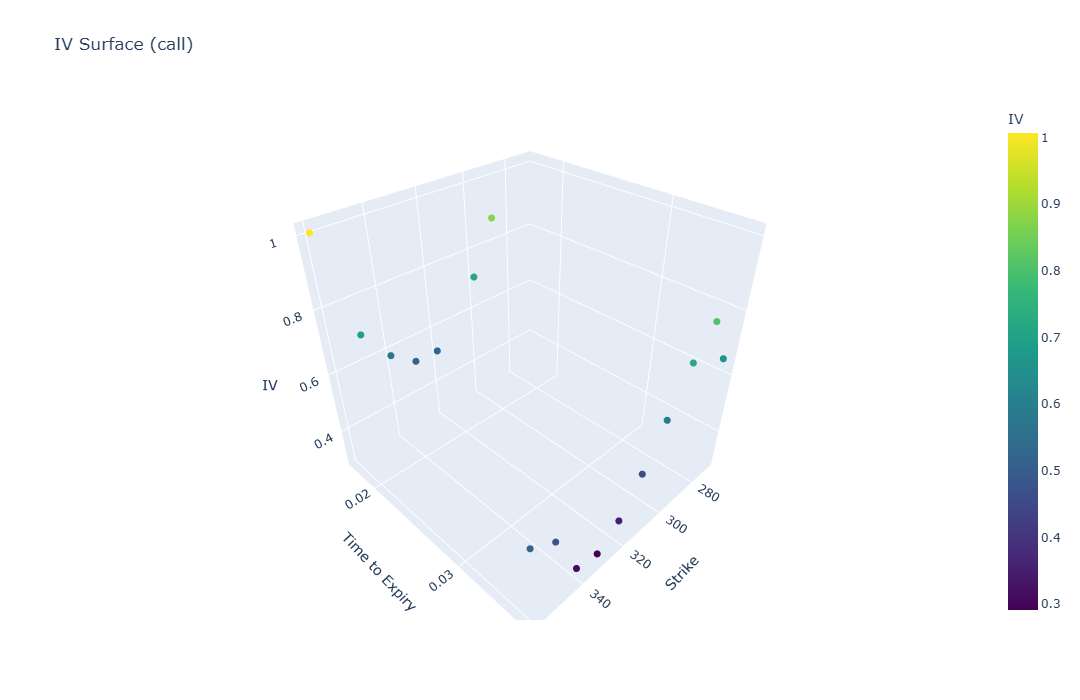

In [15]:
import plotly.graph_objects as go
import numpy as np
from scipy.interpolate import griddata

df_plot = df[df['IV'].notna()]

x = df_plot['strike'].values
y = df_plot['time_to_expiry'].values
z = df_plot['IV'].values

xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((x, y), z, (xi, yi), method='cubic')

fig = go.Figure(data=[go.Scatter3d(
    x=df_plot['strike'],
    y=df_plot['time_to_expiry'],
    z=df_plot['IV'],
    mode='markers',
    marker=dict(
        size=4,
        color=df_plot['IV'],
        colorscale='Viridis',
        colorbar=dict(title='IV')
    )
)])

fig.update_layout(
    title='IV Surface (call)',
    scene=dict(
        xaxis_title='Strike',
        yaxis_title='Time to Expiry',
        zaxis_title='IV',
    ),
    width=900, height=700
)

fig.show()